# Time-varying Neural Dynamics

**This project is the final project for Brown APMA 1360 Applied Dynamical Systems**

This is the final report for generating required figures.

## Import

In [1]:
# %matplotlib widget
import numpy as np
import jPCA
import matplotlib.pyplot as plt
from jPCA.util import load_churchland_data, plot_projections, preprocess
from utils import plot_3d_projections

## Read Data

We are going to use the example data provided by the Churchland group used for original jPCA paper where a monkey performed delayed reaching tasks. The data read in is 

$$X \in \reals^{C \times T \times N}$$

where N is the number of neurons (218), and C is the number of conditions.

In [2]:
path = "exampleData.mat"
data, times = load_churchland_data(path)

print(f"Number of conditions: {len(data)}")
print(f"Number of neurons: {data[0].shape[1]}")
print(f"Number of time points: {data[0].shape[0]}")

print(f"Time range: {times[0]} to {times[-1]} ms.")
print(f"Sampling rate: {1 / np.mean(np.diff(times)/1000):.2f} Hz.")

Number of conditions: 108
Number of neurons: 218
Number of time points: 61
Time range: -50 to 550 ms.
Sampling rate: 100.00 Hz.


The data loaded is a list of conditions. There are 108 conditions in total, and for each condition, there is an numpy array of shape `(61, 218)`

Average firing rate across conditions: (61, 218)


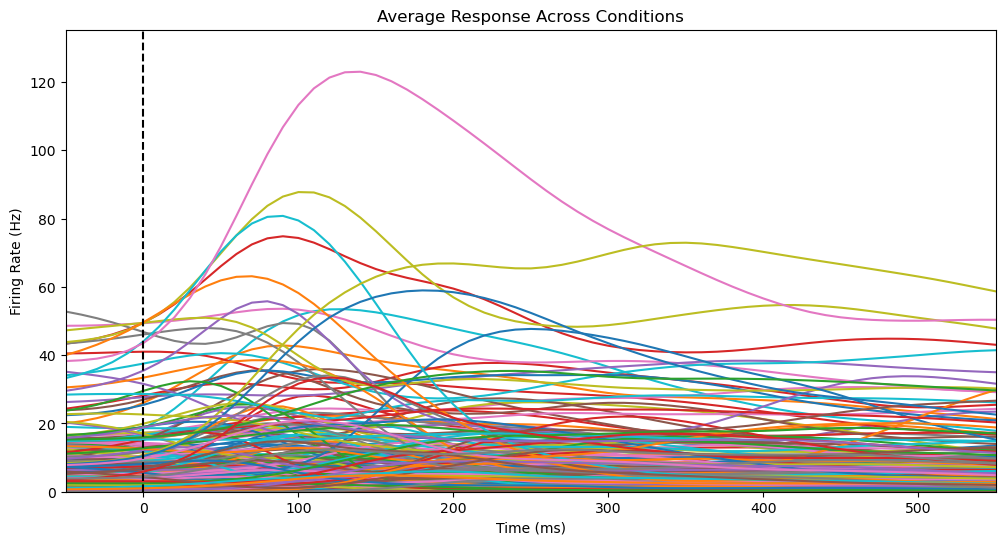

In [3]:
# Plot some data
average_data = np.mean(data, axis=0)
print(f"Average firing rate across conditions: {average_data.shape}")

# Firing rates of each channel
plt.figure(figsize=(12, 6))
plt.plot(times, average_data)
plt.title("Average Response Across Conditions")
plt.xlabel("Time (ms)")
plt.ylabel("Firing Rate (Hz)")
plt.xlim(times[0], times[-1])
plt.ylim(0, np.max(average_data) * 1.1)
plt.axvline(0, color='k', linestyle='--', label='Movement Onset')
plt.show()

## Preprocessing

Preprocessing includes soft normalization, mean subtraction, and PCA. Here we just utilize the preprocessing method in the toolbox.

Data shape after preprocessing: (108, 21, 6)


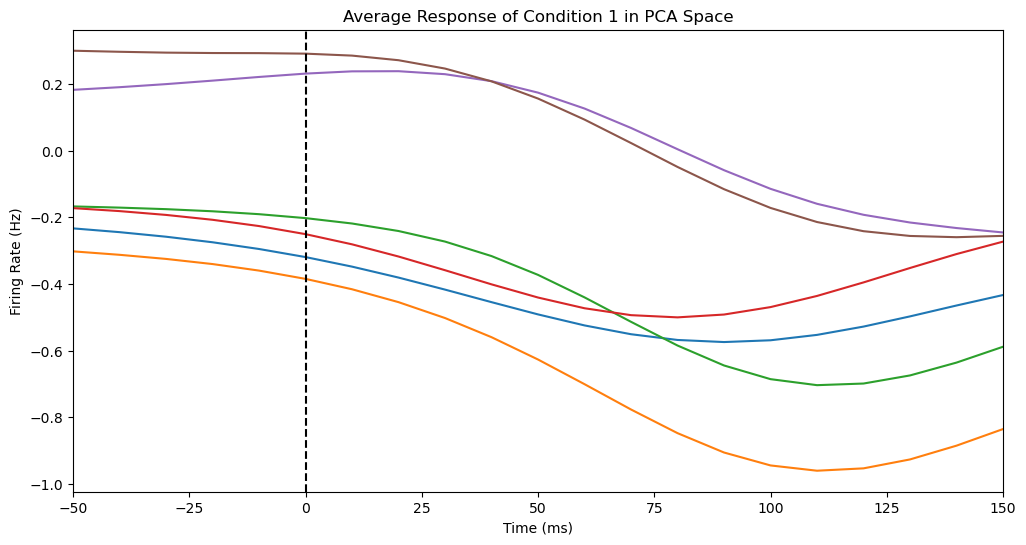

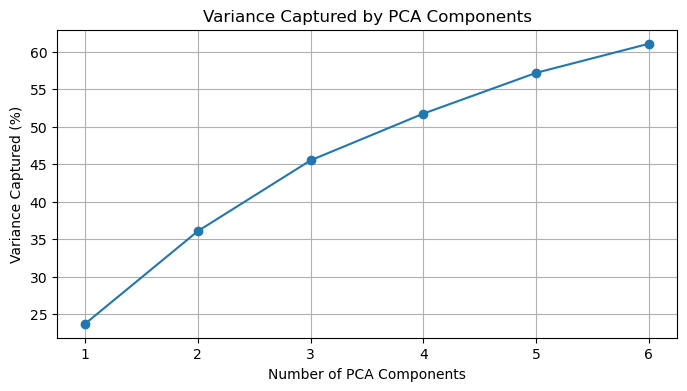

In [6]:
data_list, full_data_var, pca_variance_captured = preprocess(data, times, tstart=-50, tend=150)
times = [t for t in times if -50 <= t <= 150]
data_reduced = np.stack(data_list, axis=0)
print(f"Data shape after preprocessing: {data_reduced.shape}")

# Plot some data
# Firing rates of each channel
plt.figure(figsize=(12, 6))
plt.plot(times, data_list[0])
plt.title("Average Response of Condition 1 in PCA Space")
plt.xlabel("Time (ms)")
plt.ylabel("Firing Rate (Hz)")
plt.xlim(times[0], times[-1])
# plt.ylim(0, np.max(average_data) * 1.1)
plt.axvline(0, color='k', linestyle='--', label='Movement Onset')
plt.show()

# Plot the variance ratio captured by PCA
ratio_captured = pca_variance_captured / full_data_var
ratio_captured_cumsum = np.cumsum(ratio_captured)
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(ratio_captured_cumsum) + 1), ratio_captured_cumsum * 100, marker='o')
plt.title("Variance Captured by PCA Components")
plt.xlabel("Number of PCA Components")
plt.ylabel("Variance Captured (%)")
plt.grid()
plt.show()

## Dynamics in PCA space

We can now visualize the neural dynamics in the PCA space. We are only ploting the top 3 PCs. Note that here's the entire trial from -50 ms to 550 ms.

### Plot the trajectories

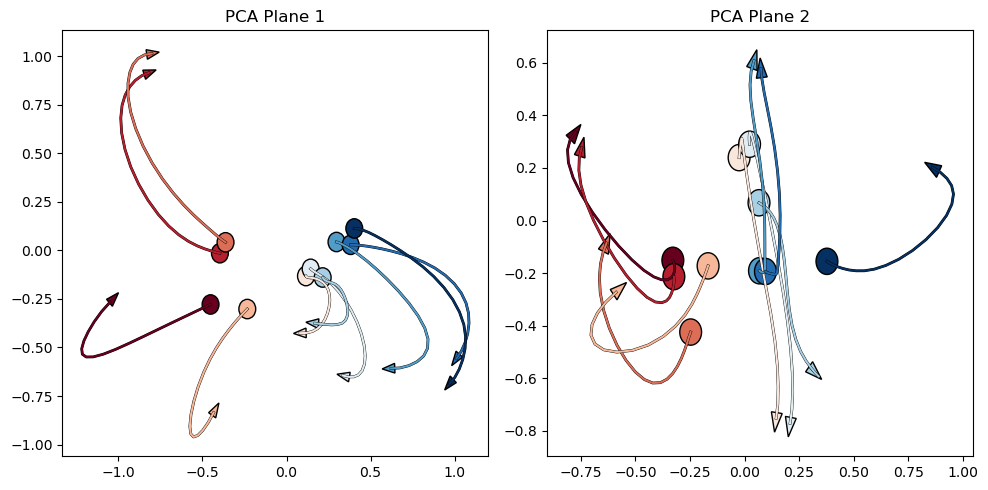

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_projections(data_list[0:10], axis=axes[0], x_idx=0, y_idx=1)
plot_projections(data_list[0:10], axis=axes[1], x_idx=2, y_idx=3)

axes[0].set_title("PCA Plane 1")
axes[1].set_title("PCA Plane 2")
plt.tight_layout()
plt.show()

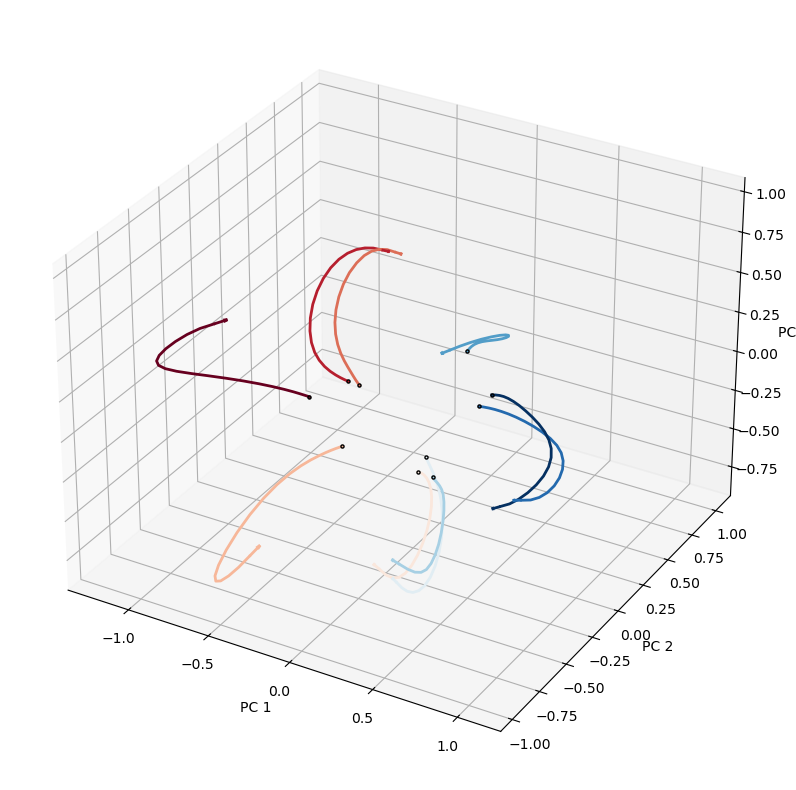

In [8]:
fig = plt.figure(figsize=(8, 8))
axis = fig.add_subplot(111, projection='3d')
plot_3d_projections(data_list[0:10], axis=axis, x_idx=0, y_idx=1, z_idx=2)

axis.set_xlabel('PC 1')
axis.set_ylabel('PC 2')
axis.set_zlabel('PC 3')
plt.tight_layout()
plt.show()

### Fit the dynamics

Try the unconstraint neural dynamics in the PCA space first. We assume the dynamics to be:

$$\dot{x} = Mx$$

where $\dot{x} = x(t+1) - x(t)$. Therefore, 

$$M = \argmin ||\dot{X} - MX||_F^2$$

Shape of X for Dynamics: (2160, 6)
Shape of X_dot for Dynamics: (2160, 6)


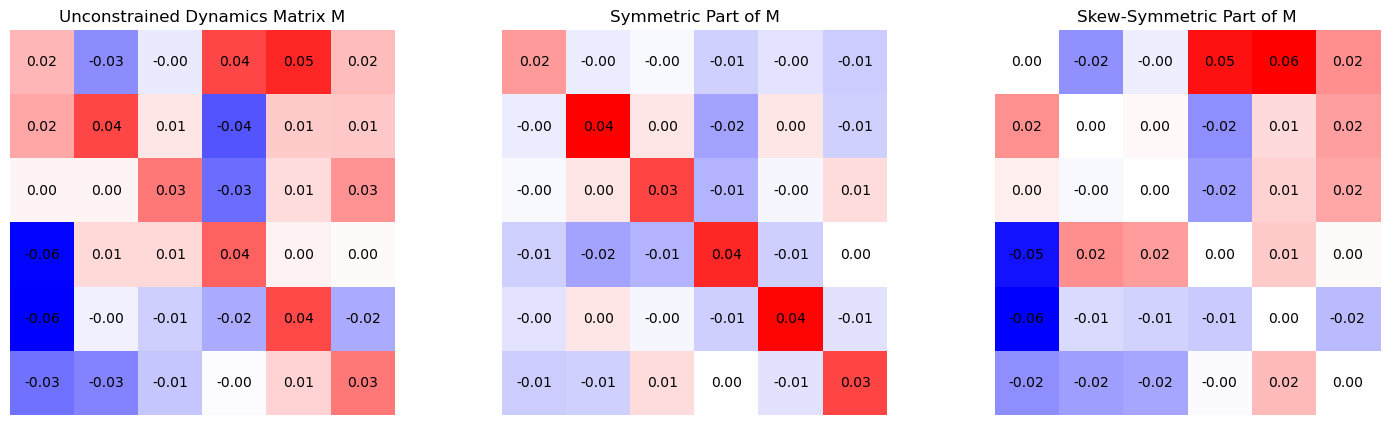

In [14]:
X = np.concatenate([x[:-1] for x in data_list])
print(f"Shape of X for Dynamics: {X.shape}")
X_dot = np.concatenate([np.diff(x, axis=0) for x in data_list])
print(f"Shape of X_dot for Dynamics: {X_dot.shape}")

# HACK: This might not be the best way to handle the last time point
# but this is how they did it in the original jPCA code, so we'll follow that for now.

# Unconstrained Dynamics
M = np.linalg.lstsq(X, X_dot, rcond=None)[0]

# Decomposing M into symmetric and skew-symmetric parts
M_symmetric = 0.5 * (M + M.T)
M_skew = 0.5 * (M - M.T)

# Plot the matrix M as a heatmap
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(M, cmap='bwr', vmin=-np.max(np.abs(M)), vmax=np.max(np.abs(M)))
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        plt.text(j, i, f"{M[i, j]:.2f}", ha='center', va='center', color='black')
plt.title("Unconstrained Dynamics Matrix M")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(M_symmetric, cmap='bwr', vmin=-np.max(np.abs(M_symmetric)), vmax=np.max(np.abs(M_symmetric)))
for i in range(M_symmetric.shape[0]):
    for j in range(M_symmetric.shape[1]):
        plt.text(j, i, f"{M_symmetric[i, j]:.2f}", ha='center', va='center', color='black')
plt.title("Symmetric Part of M")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(M_skew, cmap='bwr', vmin=-np.max(np.abs(M_skew)), vmax=np.max(np.abs(M_skew)))
for i in range(M_skew.shape[0]):
    for j in range(M_skew.shape[1]):
        plt.text(j, i, f"{M_skew[i, j]:.2f}", ha='center', va='center', color='black')
plt.title("Skew-Symmetric Part of M")
plt.axis('off')
plt.show()